# Posterior predictive eccentricity distribution (global-sigma model)

The posterior predictive distribution (PPD) of the 10 Hz eccentricity for the capture
population, from the **global-sigma model**. The capture model tabulates
$p(\log_{10} e \mid \sigma, M_{\rm tot}, \mu)$ in `hierarchical_inference/capture_ecc_table.h5`;
the PPD marginalizes it over

- the **full velocity-dispersion hyperposterior** $p(\sigma \mid \mathrm{data})$
  (`hierarchical_inference/sigma_posterior.h5`, column `sigma`, cgs cm/s), and
- the **population mass distribution** $p(m_1, q \mid \lambda)$ from the GWTC-4 gwpopulation
  mass model, evaluated per draw and converted to $(M_{\rm tot}, \mu)$.

Both are taken jointly per posterior draw, so $\sigma$–mass correlations propagate into the
band (green). The blue/red curves are single-environment references at fixed typical
dispersions — a globular cluster (GC, $\sigma = 10$ km/s) and a nuclear star cluster
(NSC, $\sigma = 100$ km/s), masses at the posterior median.

Overlaid in grey are the **individual per-event eccentricity posteriors** reweighted to a
log-uniform $e$ prior (`event_data/posteriors_log_uniform_eccentric.h5`) — a histogram density,
lightly smoothed, drawn as a line per event. The dotted line at $e=0.05$ splits the
(in)distinguishable-from-circular regions. Companion: the GC/NSC branching-fraction (beta)
mixture is in `velocity_dispersion_posterior.ipynb`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Robust path: find the release code/ dir (has models/ + scripts/).
def _find_code_root():
    d = os.path.abspath(os.getcwd())
    for _ in range(6):
        if os.path.isdir(os.path.join(d, "models")) and os.path.isdir(os.path.join(d, "scripts")):
            return d
        d = os.path.dirname(d)
    return os.path.abspath("..")

CODE = _find_code_root()
sys.path.insert(0, CODE)
sys.path.insert(0, os.path.join(CODE, "scripts"))
sys.path.insert(0, os.path.join(CODE, "style"))
from config import DATA_ROOT, HIERARCHICAL_DIR, EVENT_DATA_DIR
from download_data import download_all
from plot_style import COLORS, initialize_latex

import gwpopulation
gwpopulation.set_backend("numpy")
from models.mass import TwoPeakBrokenPowerLawSmoothedMassDistribution

initialize_latex()
C_PPD = COLORS["green"]    # global-sigma PPD
C_GC = COLORS["blue"]      # typical globular cluster
C_NSC = COLORS["red"]      # typical nuclear star cluster
C_EVENT = COLORS["grey"]

# Shipped inputs: the capture eccentricity table, our velocity-dispersion (sigma)
# hyperposterior, and the per-event posteriors reweighted to a log-uniform e prior.
TABLE = os.path.join(HIERARCHICAL_DIR, "capture_ecc_table.h5")
SIGMA = os.path.join(HIERARCHICAL_DIR, "sigma_posterior.h5")
EVENTS_LU = os.path.join(EVENT_DATA_DIR, "posteriors_log_uniform_eccentric.h5")
if not all(os.path.exists(p) for p in (TABLE, SIGMA, EVENTS_LU)):
    download_all()

post = pd.read_hdf(SIGMA, key="posterior")
mass_model = TwoPeakBrokenPowerLawSmoothedMassDistribution(mmin=2.0, mmax=300.0)
MASS_KEYS = ["alpha_1", "alpha_2", "beta", "break_mass", "lam_0", "lam_1",
             "mpp_1", "mpp_2", "sigpp_1", "sigpp_2", "mlow_1", "mlow_2",
             "delta_m_1", "delta_m_2", "mmax"]
print(f"{len(post)} hyperposterior draws loaded")


def band(ax, grid, draws, color, label, pct=(5, 95), n_lines=30):
    """Median + percentile band + a few sample draws (same style as gwtc4_population)."""
    good = np.isfinite(draws).all(axis=1)
    d = draws[good] if good.any() else draws
    lo, med, hi = np.nanpercentile(d, [pct[0], 50, pct[1]], axis=0)
    sub = d[np.random.default_rng(42).choice(len(d), size=min(n_lines, len(d)), replace=False)]
    for s in sub:
        ax.plot(grid, s, color=color, lw=0.4, alpha=0.12)
    ax.fill_between(grid, lo, hi, color=color, alpha=0.22, lw=0)
    ax.plot(grid, med, color=color, lw=2.2, label=label, zorder=6)

6560 hyperposterior draws loaded


In [2]:
# ---- Global-sigma PPD of log10 e: one mass-marginalized curve per hyperposterior draw ----
# Same shape as gwtc4_population's `population_densities`: for each draw evaluate a density
# curve on a fixed grid, then `band()` takes percentiles across draws. Eccentricity is not a
# direct output of the population model -- it comes from the capture table
# p(log10 e | sigma, Mtot, mu) -- so each draw's curve is the population-mass-weighted average
# of that table at the draw's sigma (drawn jointly with the masses from the sigma posterior).
with h5py.File(TABLE) as f:
    Mtot_grid = f["Mtot_grid"][:]      # Msun
    mu_grid = f["mu_grid"][:]          # Msun
    e_centers = f["e_centers"][:]
    sigma_grid = f["sigma_grid"][:]    # cgs cm/s
    table = f["table"][:]              # (sigma, Mtot, mu, e) -> p(log10 e | sigma, M, mu)
log10_e_tab = np.log10(e_centers)
log10_sig_grid = np.log10(sigma_grid)
nE, nU = len(e_centers), len(mu_grid)

# Population (m1, q) grid; each cell maps to (Mtot, mu) = (m1(1+q), m1 q/(1+q)); precompute the
# bilinear weights into the table's (Mtot, mu) nodes (both log-spaced).
m1_grid = np.linspace(2.0, 120.0, 50)
q_grid = np.linspace(0.05, 1.0, 30)
M1, Q = np.meshgrid(m1_grid, q_grid, indexing="ij")
mass_samples = {"mass_1": M1.ravel(), "mass_ratio": Q.ravel()}
_Mtot = M1.ravel() * (1.0 + Q.ravel())
_mu = M1.ravel() * Q.ravel() / (1.0 + Q.ravel())

def _wts(grid, x):
    x = np.clip(x, grid[0], grid[-1])
    j = np.clip(np.searchsorted(grid, x) - 1, 0, len(grid) - 2)
    return j, (x - grid[j]) / (grid[j + 1] - grid[j])

_jM, _wM = _wts(np.log10(Mtot_grid), np.log10(_Mtot))
_jU, _wU = _wts(np.log10(mu_grid), np.log10(_mu))
_corner = (_jM * nU + _jU, (_jM + 1) * nU + _jU, _jM * nU + (_jU + 1), (_jM + 1) * nU + (_jU + 1))
_cw = (((1 - _wM) * (1 - _wU))[:, None], (_wM * (1 - _wU))[:, None],
       ((1 - _wM) * _wU)[:, None], (_wM * _wU)[:, None])


def ecc_table_at(sigma_cms):
    """p(log10 e | sigma, m1, q) for every (m1, q) cell, at one sigma (cgs cm/s)."""
    ls = np.clip(np.log10(sigma_cms), log10_sig_grid[0], log10_sig_grid[-1])
    j = int(np.clip(np.searchsorted(log10_sig_grid, ls) - 1, 0, len(log10_sig_grid) - 2))
    w = (ls - log10_sig_grid[j]) / (log10_sig_grid[j + 1] - log10_sig_grid[j])
    slabF = ((1 - w) * table[j] + w * table[j + 1]).reshape(-1, nE)   # (Mtot*mu, e)
    return sum(c * slabF[i] for c, i in zip(_cw, _corner))            # (cells, e)


def ecc_densities(draws, sigma, idx):
    """p(log10 e) per draw, marginalized over the population masses (cf. population_densities)."""
    out = np.full((len(idx), nE), np.nan)
    for ii, k in enumerate(idx):
        mp = {kk: float(draws[kk][k]) for kk in MASS_KEYS}
        w = np.clip(np.nan_to_num(np.asarray(mass_model(mass_samples, **mp))), 0.0, None)
        if w.sum() <= 0:
            continue
        out[ii] = (w / w.sum()) @ ecc_table_at(sigma[k])
    return out


post_arr = {kk: post[kk].to_numpy(float) for kk in MASS_KEYS}
sig_arr = post["sigma"].to_numpy(float)   # cgs cm/s, jointly with the masses per draw
sel = np.random.default_rng(42).choice(len(post), size=min(800, len(post)), replace=False)
ppd = ecc_densities(post_arr, sig_arr, sel)

# Reference single-environment curves at fixed typical dispersions, mass-marginalized at the
# posterior-median masses: GC ~ 10 km/s, NSC ~ 100 km/s.
mp_med = {kk: float(np.median(post_arr[kk])) for kk in MASS_KEYS}
w_med = np.clip(np.nan_to_num(np.asarray(mass_model(mass_samples, **mp_med))), 0.0, None)
w_med /= w_med.sum()
gc_curve = w_med @ ecc_table_at(10.0 * 1e5)    # typical GC
nsc_curve = w_med @ ecc_table_at(100.0 * 1e5)  # typical NSC

print(f"PPD over {int(np.isfinite(ppd).all(axis=1).sum())} draws; "
      f"median curve integral over log10 e = {np.trapezoid(np.nanmedian(ppd, axis=0), log10_e_tab):.3f}")

/work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/models/mass.py:132: RuntimeWarning: invalid value encountered in divide
  return xp.nan_to_num(p_q / norm_at_samples)


/work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/.venv/lib/python3.11/site-packages/gwpopulation/utils.py:165: RuntimeWarning: divide by zero encountered in log
  return log_p + xp.log(1 - xp.exp(log_q - log_p))
/work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/.venv/lib/python3.11/site-packages/gwpopulation/utils.py:178: RuntimeWarning: divide by zero encountered in log1p
  xp.log1p(-scs.ndtr(aa) - scs.ndtr(-bb)),


PPD over 800 draws; median curve integral over log10 e = 0.906


In [3]:
# ---- Per-event eccentricity posteriors under a log-uniform e prior ----
# Each event's reweighted samples -> a normalized density in log10 e, drawn as a line, so the
# individual measurements can be compared to the population PPD. Events with no eccentricity
# information return the (flat-in-log10-e) prior; informative events deviate.
#
# The log-uniform reweighting leaves a low effective sample size (heavy weights in the high-e
# tail), so the raw histogram is spiky -> bin finely and apply a light Gaussian smoothing.
# reflect mode keeps the flat, uninformative events flat to the boundaries.
ev_edges = np.linspace(-4.0, 0.0, 81)
ev_ctr = 0.5 * (ev_edges[:-1] + ev_edges[1:])
EV_SMOOTH = 2.0   # smoothing scale in bins (~0.1 dex)

event_curves = {}
with h5py.File(EVENTS_LU) as f:
    ev_names = [k for k in f.keys() if isinstance(f[k], h5py.Group) and "samples" in f[k]]
    for name in ev_names:
        e = f[name]["samples"]["eccentricity"][:]
        w = f[name]["samples"]["weights"][:]
        le = np.log10(np.clip(e, 10 ** -4.0, None))
        dens, _ = np.histogram(le, bins=ev_edges, weights=w, density=True)
        event_curves[name] = gaussian_filter1d(dens, EV_SMOOTH, mode="reflect")
print(f"{len(event_curves)} per-event log-uniform posteriors (smoothed)")

84 per-event log-uniform posteriors (smoothed)


wrote ppd_eccentricity.pdf


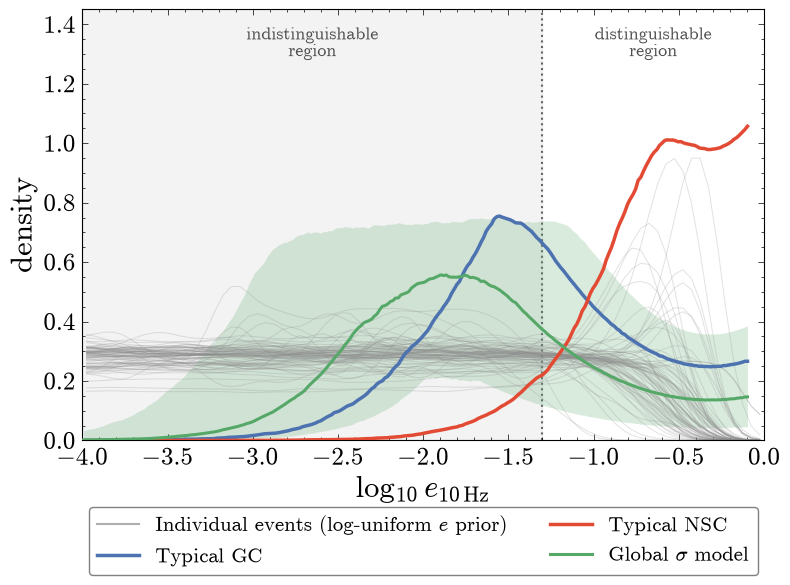

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

# e = 0.05 splits the (in)distinguishable-from-circular regions.
E_DIV = np.log10(0.05)
trans = ax.get_xaxis_transform()   # x in data, y in axes fraction
ax.axvspan(-4, E_DIV, color=COLORS["grey"], alpha=0.10, zorder=0)
ax.axvline(E_DIV, color="0.4", ls=":", lw=1.5, zorder=1)
ax.text(0.5 * (-4 + E_DIV), 0.96, "indistinguishable\nregion", transform=trans,
        ha="center", va="top", fontsize=13, color="0.30")
ax.text(0.5 * (E_DIV + 0), 0.96, "distinguishable\nregion", transform=trans,
        ha="center", va="top", fontsize=13, color="0.30")

# individual events: smoothed histogram density, thin grey lines ...
for dens in event_curves.values():
    ax.plot(ev_ctr, dens, color=C_EVENT, lw=0.7, alpha=0.25, zorder=2)
ax.plot([], [], color=C_EVENT, lw=1.5, alpha=0.7,
        label="Individual events (log-uniform $e$ prior)")

# ... typical GC / NSC reference curves ...
ax.plot(log10_e_tab, gc_curve, color=C_GC, lw=2.5, zorder=5, label="Typical GC")
ax.plot(log10_e_tab, nsc_curve, color=C_NSC, lw=2.5, zorder=5, label="Typical NSC")

# ... and the global-sigma PPD band + median on top.
band(ax, log10_e_tab, ppd, C_PPD, r"Global $\sigma$ model", n_lines=0)

ax.set_xlabel(r"$\log_{10} e_{10\,\mathrm{Hz}}$", fontsize=22)
ax.set_ylabel("density", fontsize=22)
ax.set_xlim(-4, 0)
ax.set_ylim(0, 1.45)
ax.tick_params(labelsize=18)
ax.legend(frameon=True, edgecolor="grey", framealpha=1.0, fontsize=15,
          loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
fig.tight_layout()
fig.savefig("../figures/ppd_eccentricity.pdf", bbox_inches="tight")
print("wrote ppd_eccentricity.pdf")

wrote ppd_eccentricity_distinguishable.pdf


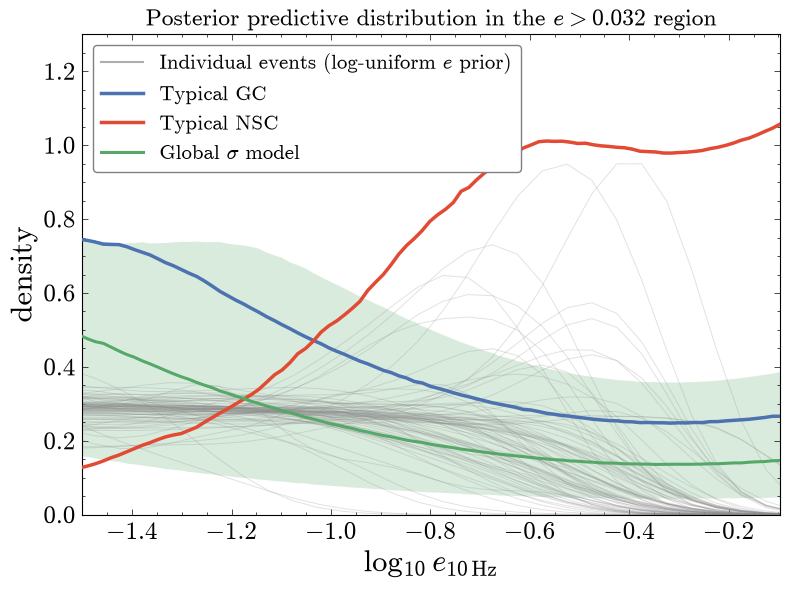

In [5]:
# ---- Zoom: 0.032 (= 10^-1.5) < e < 0.8, legend inside ----
E_LO = -1.5
E_HI = np.log10(0.8)
fig, ax = plt.subplots(figsize=(8, 6))

# individual events: smoothed histogram density, thin grey lines ...
for dens in event_curves.values():
    ax.plot(ev_ctr, dens, color=C_EVENT, lw=0.7, alpha=0.25, zorder=2)
ax.plot([], [], color=C_EVENT, lw=1.5, alpha=0.7,
        label="Individual events (log-uniform $e$ prior)")
ax.plot(log10_e_tab, gc_curve, color=C_GC, lw=2.5, zorder=5, label="Typical GC")
ax.plot(log10_e_tab, nsc_curve, color=C_NSC, lw=2.5, zorder=5, label="Typical NSC")
band(ax, log10_e_tab, ppd, C_PPD, r"Global $\sigma$ model", n_lines=0)

ax.set_xlabel(r"$\log_{10} e_{10\,\mathrm{Hz}}$", fontsize=22)
ax.set_ylabel("density", fontsize=22)
ax.set_xlim(E_LO, E_HI)        # 0.032 < e < 0.8
ax.set_ylim(0, 1.3)
ax.tick_params(labelsize=18)
ax.set_title(r"Posterior predictive distribution in the $e > 0.032$ region", fontsize=17)
ax.legend(frameon=True, edgecolor="grey", framealpha=1.0, fontsize=15, loc="upper left")
fig.tight_layout()
fig.savefig("../figures/ppd_eccentricity_distinguishable.pdf", bbox_inches="tight")
print("wrote ppd_eccentricity_distinguishable.pdf")